# M3 - Transfer Learning với MobileNetV2


Pipeline gồm:
1. Nạp bộ chia cố định và kiểm tra rò rỉ dữ liệu.
2. Huấn luyện classifier với backbone MobileNetV2 được đóng băng.
3. Fine-tune các block cuối của backbone.
4. Chọn checkpoint tốt nhất trên validation và đánh giá một lần trên test.

Có thể điều chỉnh các siêu tham số trong cell **Cấu hình** trước khi huấn luyện.

In [10]:
from pathlib import Path
import sys

PROJECT_DIR = Path.cwd()
if PROJECT_DIR.name == "notebooks":
    PROJECT_DIR = PROJECT_DIR.parent
sys.path.insert(0, str(PROJECT_DIR))
print(f"Project: {PROJECT_DIR}")

Project: c:\Users\MY PC\Documents\DL\project 1\plant-disease-classification


In [ ]:
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torchvision.models import MobileNet_V2_Weights, mobilenet_v2
from tqdm.auto import tqdm

from src.data_utils import (
    DATA_DIR,
    make_dataloaders,
    make_transfer_transforms,
    validate_split,
)

RESULTS_DIR = PROJECT_DIR / "outputs/results"
MODELS_DIR = PROJECT_DIR / "outputs/models"


def set_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


def load_existing_split():
    split_df = pd.read_csv(RESULTS_DIR / "data_split.csv")
    class_names = json.loads(
        (RESULTS_DIR / "class_names.json").read_text(encoding="utf-8")
    )
    same_class = pd.read_csv(
        RESULTS_DIR / "same_class_near_duplicate_candidates.csv"
    )
    cross_class = pd.read_csv(
        RESULTS_DIR / "cross_class_near_duplicate_candidates.csv"
    )
    near_duplicates = pd.concat([
        same_class.loc[same_class["confirmed"], ["image_1", "image_2"]],
        cross_class.loc[cross_class["confirmed"], ["image_1", "image_2"]],
    ], ignore_index=True)
    validation = validate_split(split_df, near_duplicates, class_names)
    if validation["missing_class_rows"]:
        raise ValueError(f"Missing classes: {validation['missing_class_rows']}")
    return split_df, class_names, validation


def build_model(num_classes, weights=MobileNet_V2_Weights.DEFAULT):
    if num_classes < 2:
        raise ValueError("num_classes must be at least 2")
    model = mobilenet_v2(weights=weights)
    model.classifier[1] = nn.Linear(
        model.classifier[1].in_features, num_classes
    )
    return model


def run_epoch(model, loader, criterion, device, optimizer=None, description=None):
    training = optimizer is not None
    model.train(training)
    if training:
        model.features.eval()

    total_loss = total_correct = total_items = 0
    batches = tqdm(loader, desc=description, leave=False) if description else loader
    for images, labels in batches:
        images, labels = images.to(device), labels.to(device)
        if training:
            optimizer.zero_grad(set_to_none=True)
        with torch.set_grad_enabled(training):
            logits = model(images)
            loss = criterion(logits, labels)
            if training:
                loss.backward()
                optimizer.step()
        total_loss += loss.item() * labels.size(0)
        total_correct += (logits.argmax(1) == labels).sum().item()
        total_items += labels.size(0)
        if description:
            batches.set_postfix(loss=f"{total_loss / total_items:.4f}")

    if total_items == 0:
        raise ValueError("The data loader is empty")
    return total_loss / total_items, total_correct / total_items


def train_model(model, train_loader, validation_loader, criterion, device,
                epochs, learning_rate, phase, checkpoint_path, config):
    optimizer = torch.optim.AdamW(
        [p for p in model.parameters() if p.requires_grad],
        lr=learning_rate,
        weight_decay=1e-4,
    )
    best_key = (-1.0, float("inf"))
    best_metrics = None
    history = []

    for epoch in range(1, epochs + 1):
        train_loss, train_accuracy = run_epoch(
            model, train_loader, criterion, device, optimizer,
            f"{phase} train {epoch}/{epochs}",
        )
        validation_loss, validation_accuracy = run_epoch(
            model, validation_loader, criterion, device,
            description=f"{phase} val {epoch}/{epochs}",
        )
        record = {
            "phase": phase,
            "epoch": epoch,
            "train_loss": train_loss,
            "train_accuracy": train_accuracy,
            "validation_loss": validation_loss,
            "validation_accuracy": validation_accuracy,
        }
        history.append(record)
        key = (validation_accuracy, -validation_loss)
        if key > best_key:
            best_key = key
            best_metrics = record
            checkpoint_path.parent.mkdir(parents=True, exist_ok=True)
            torch.save({
                "model_state": model.state_dict(),
                "class_names": config["class_names"],
                "phase": phase,
                "epoch": epoch,
                "metrics": record,
                "config": config,
            }, checkpoint_path)
        print(
            f"{phase} epoch {epoch}/{epochs} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {validation_loss:.4f} | "
            f"val acc {validation_accuracy:.4f}"
        )
    return history, best_metrics


@torch.inference_mode()
def evaluate_model(model, loader, class_names, device, output_dir, prefix):
    model.eval()
    labels, predictions = [], []
    for images, batch_labels in loader:
        predictions.extend(model(images.to(device)).argmax(1).cpu().tolist())
        labels.extend(batch_labels.tolist())

    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    report = classification_report(
        labels, predictions, target_names=class_names,
        output_dict=True, zero_division=0,
    )
    matrix = confusion_matrix(labels, predictions, labels=range(len(class_names)))
    metrics = {
        "accuracy": float((labels == predictions).mean()),
        "macro_f1": float(f1_score(
            labels, predictions, labels=range(len(class_names)),
            average="macro", zero_division=0,
        )),
        "classification_report": report,
        "confusion_matrix": matrix.tolist(),
    }
    output_dir.mkdir(parents=True, exist_ok=True)
    pd.DataFrame(report).transpose().to_json(
        output_dir / f"{prefix}_classification_report.json", indent=2
    )
    pd.DataFrame(matrix).to_csv(
        output_dir / f"{prefix}_confusion_matrix.csv", index=False
    )
    return metrics


## Cấu hình

In [12]:
SEED = 42
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
PHASE1_EPOCHS, PHASE2_EPOCHS = 5, 5
PHASE1_LR, PHASE2_LR = 1e-3, 1e-4
UNFREEZE_LAST_BLOCKS = 3
BATCH_SIZE, NUM_WORKERS = 32, 0
set_seed(SEED)
print(f"Device: {DEVICE}")

Device: cuda


## Nạp split và tạo DataLoader

Notebook sử dụng cùng bộ split và các file kiểm tra ảnh trùng lặp như script M3.

In [13]:
split_df, class_names, split_validation = load_existing_split()
train_transform, eval_transform = make_transfer_transforms(MobileNet_V2_Weights.DEFAULT)
train_loader, validation_loader, test_loader = make_dataloaders(
    split_df, DATA_DIR, train_transform, eval_transform,
    batch_size=BATCH_SIZE, num_workers=NUM_WORKERS,
)
print(f"Classes: {len(class_names)}")
print(split_df["split"].value_counts().to_dict())
print(f"Group leaks: {len(split_validation['leaking_groups'])}")
print(f"Near-duplicate leaks: {len(split_validation['near_pair_leaks'])}")

Classes: 38
{'train': 37984, 'test': 10873, 'validation': 5427}
Group leaks: 0
Near-duplicate leaks: 0


## Xây dựng model và cấu hình checkpoint

In [ ]:
weights = MobileNet_V2_Weights.DEFAULT
model = build_model(len(class_names), weights=weights).to(DEVICE)
criterion = torch.nn.CrossEntropyLoss()
config = {
    "seed": SEED,
    "device": str(DEVICE),
    "data_dir": str(DATA_DIR),
    "class_names": class_names,
    "num_classes": len(class_names),
    "image_size": [224, 224],
    "pretrained_weights": "MobileNet_V2_Weights.DEFAULT",
    "split_counts": split_df["split"].value_counts().to_dict(),
    "split_validation": {
        "leaking_groups": len(split_validation["leaking_groups"]),
        "near_pair_leaks": len(split_validation["near_pair_leaks"]),
    },
    "phase_1": {"epochs": PHASE1_EPOCHS, "learning_rate": PHASE1_LR},
    "phase_2": {
        "epochs": PHASE2_EPOCHS,
        "learning_rate": PHASE2_LR,
        "unfreeze_last_blocks": UNFREEZE_LAST_BLOCKS,
    },
}
MODELS_DIR.mkdir(parents=True, exist_ok=True)
print(model.classifier)


## Phase 1 - chỉ huấn luyện classifier

In [ ]:
for parameter in model.features.parameters():
    parameter.requires_grad = False
for parameter in model.classifier.parameters():
    parameter.requires_grad = True

phase1_history, phase1_best = train_model(
    model, train_loader, validation_loader, criterion, DEVICE,
    PHASE1_EPOCHS, PHASE1_LR, "transfer_learning",
    MODELS_DIR / "mobilenet_v2_phase1_best.pt", config,
)
print("Kết quả tốt nhất phase 1:", phase1_best)


## Phase 2 - fine-tune các block cuối

In [ ]:
checkpoint = torch.load(
    MODELS_DIR / "mobilenet_v2_phase1_best.pt",
    map_location=DEVICE, weights_only=False,
)
model.load_state_dict(checkpoint["model_state"])

for parameter in model.features.parameters():
    parameter.requires_grad = False
for block in model.features[-UNFREEZE_LAST_BLOCKS:]:
    for parameter in block.parameters():
        parameter.requires_grad = True
for parameter in model.classifier.parameters():
    parameter.requires_grad = True

phase2_history, phase2_best = train_model(
    model, train_loader, validation_loader, criterion, DEVICE,
    PHASE2_EPOCHS, PHASE2_LR, "fine_tuning",
    MODELS_DIR / "mobilenet_v2_phase2_best.pt", config,
)
print("Kết quả tốt nhất phase 2:", phase2_best)


## Chọn checkpoint và đánh giá trên tập test

In [ ]:
use_phase2 = phase2_best["validation_accuracy"] >= phase1_best["validation_accuracy"]
chosen = phase2_best if use_phase2 else phase1_best
checkpoint_name = "mobilenet_v2_phase2_best.pt" if use_phase2 else "mobilenet_v2_phase1_best.pt"
chosen_path = MODELS_DIR / checkpoint_name
checkpoint = torch.load(chosen_path, map_location=DEVICE, weights_only=False)
model.load_state_dict(checkpoint["model_state"])

metrics = evaluate_model(
    model, test_loader, class_names, DEVICE,
    RESULTS_DIR, "mobilenet_v2_test",
)
history = pd.DataFrame(phase1_history + phase2_history)
history.to_csv(RESULTS_DIR / "mobilenet_v2_history.csv", index=False)

config["selected_checkpoint"] = str(chosen_path)
config["selected_validation_metrics"] = chosen
config["test_metrics"] = {
    "accuracy": metrics["accuracy"],
    "macro_f1": metrics["macro_f1"],
}
(RESULTS_DIR / "mobilenet_v2_config.json").write_text(
    json.dumps(config, ensure_ascii=False, indent=2), encoding="utf-8"
)
print(f"Checkpoint: {chosen_path}")
print(f"Test accuracy: {metrics['accuracy']:.4f}")
print(f"Test macro F1: {metrics['macro_f1']:.4f}")


## Đường cong huấn luyện

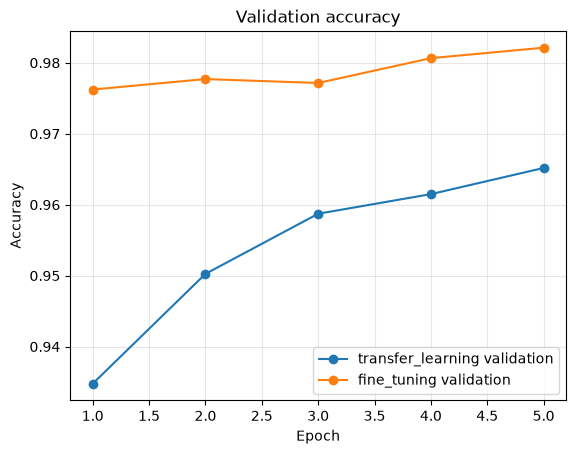

In [16]:
import matplotlib.pyplot as plt
for phase, values in history.groupby("phase", sort=False):
    plt.plot(values["epoch"], values["validation_accuracy"], marker="o", label=f"{phase} validation")
plt.title("Validation accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

## Báo cáo phân loại và ma trận nhầm lẫn

,precision,recall,f1-score,support
Apple___Apple_scab,0.953846,0.984127,0.968750,126.000000
Apple___Black_rot,1.000000,0.984000,0.991935,125.000000
Apple___Cedar_apple_rust,0.763889,1.000000,0.866142,55.000000
Apple___healthy,0.967456,0.993921,0.980510,329.000000
Blueberry___healthy,0.996678,0.996678,0.996678,301.000000
Cherry_(including_sour)___Powdery_mildew,0.990610,1.000000,0.995283,211.000000
Cherry_(including_sour)___healthy,1.000000,0.976471,0.988095,170.000000
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot,0.910112,0.786408,0.843750,103.000000
Corn_(maize)___Common_rust_,0.995798,0.991632,0.993711,239.000000
Corn_(maize)___Northern_Leaf_Blight,0.892019,0.964467,0.926829,197.000000


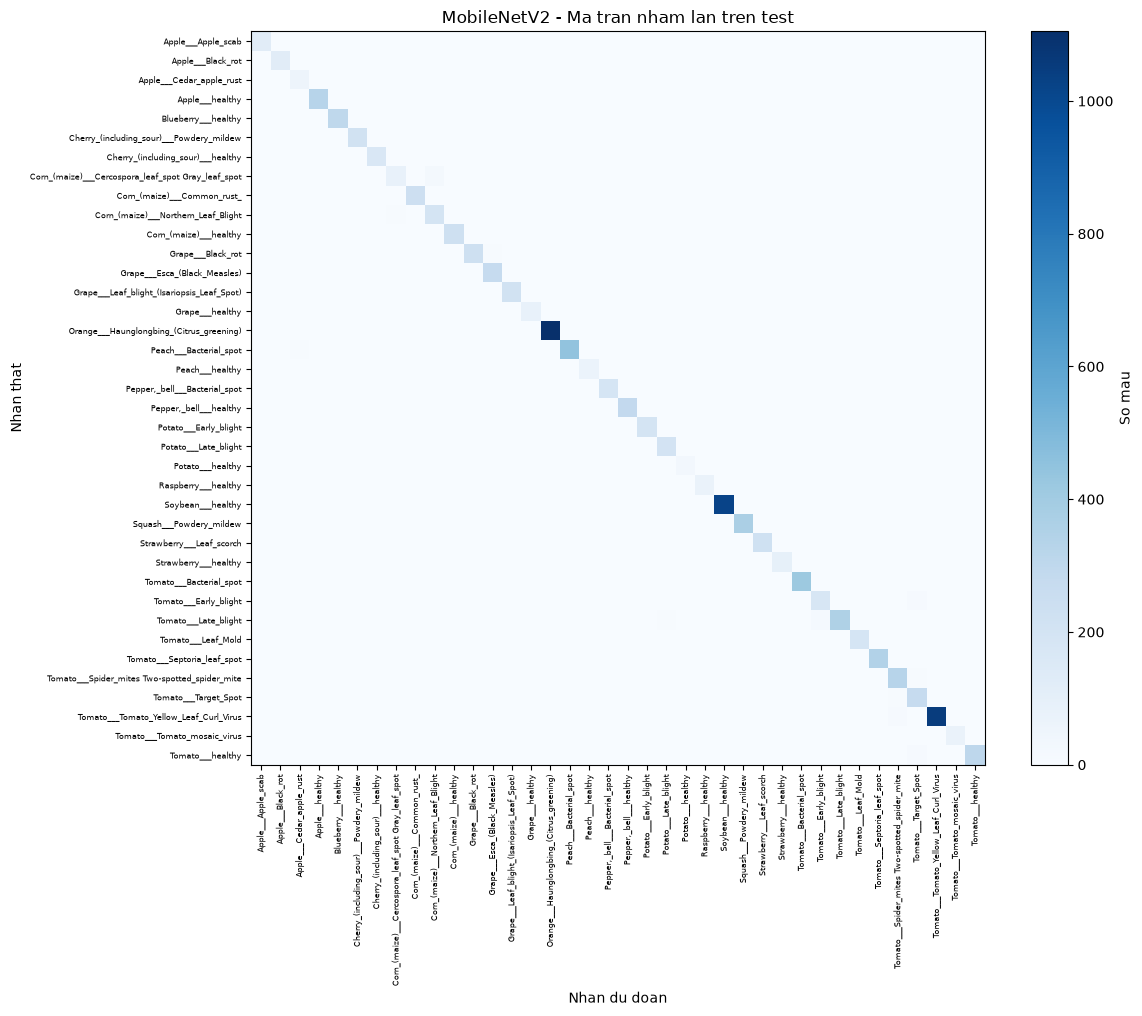

In [17]:
report = pd.DataFrame(metrics["classification_report"]).transpose()
display(report)

plt.figure(figsize=(12, 10))
plt.imshow(metrics["confusion_matrix"], cmap="Blues")
plt.colorbar(label="So mau")
plt.title("MobileNetV2 - Ma tran nham lan tren test")
plt.xlabel("Nhan du doan")
plt.ylabel("Nhan that")
plt.xticks(range(len(class_names)), class_names, rotation=90, fontsize=6)
plt.yticks(range(len(class_names)), class_names, fontsize=6)
plt.tight_layout()
plt.show()